In [37]:
# !pip install catboost

In [38]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import TargetEncoder
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [39]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  ...  AveOccup  Latitude  Longitude
0  8.3252      41.0  6.984127  ...  2.555556     37.88    -122.23
1  8.3014      21.0  6.238137  ...  2.109842     37.86    -122.22
2  7.2574      52.0  8.288136  ...  2.802260     37.85    -122.24
3  5.6431      52.0  5.817352  ...  2.547945     37.85    -122.25
4  3.8462      52.0  6.281853  ...  2.181467     37.85    -122.25

[5 rows x 8 columns]

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


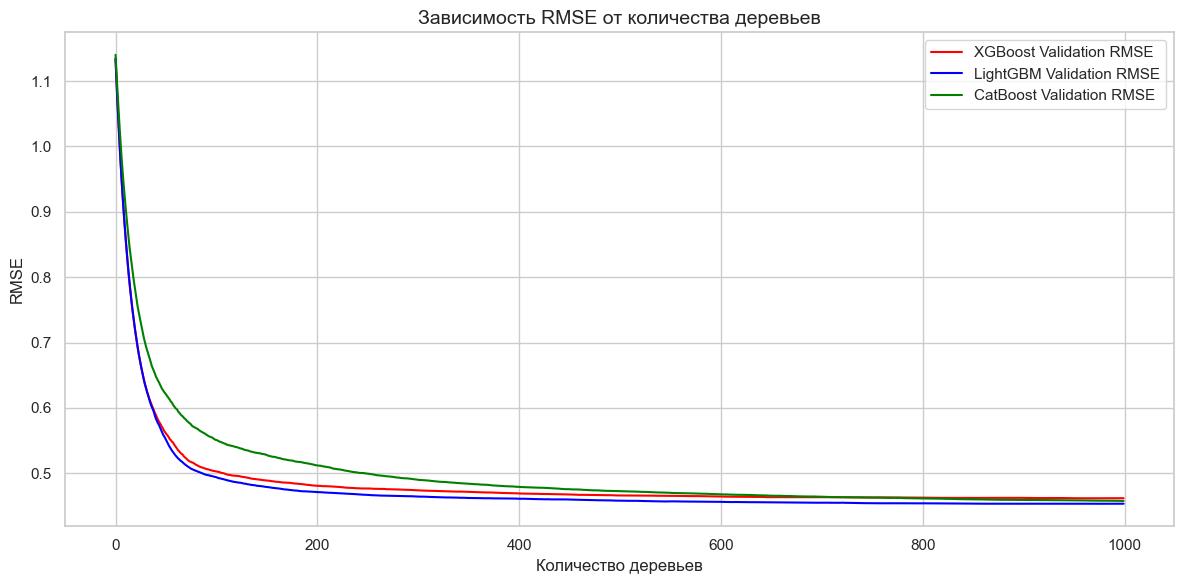

In [40]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
SELECTED_N_ESTIMATORS = 400

In [42]:
my_X_train = X_train.copy()
my_X_train['cat'] = np.full((my_X_train.shape[0]), 'a')

cats = my_X_train.select_dtypes('str').columns

encoder = TargetEncoder(random_state=42)

my_X_train[cats] = encoder.fit_transform(my_X_train[cats], y_train)
my_X_train


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,cat
17244,2.3681,39.0,3.922460,1.018717,1404.0,3.754011,34.43,-119.67,2.059550
8817,10.1357,24.0,7.564516,0.985112,2248.0,2.789082,33.74,-118.32,2.070889
19686,1.6719,41.0,3.908012,0.916914,856.0,2.540059,39.13,-121.62,2.066894
3545,4.8333,9.0,5.201093,1.009836,1884.0,2.059016,34.24,-118.63,2.059550
17019,5.5902,38.0,7.010127,0.979747,994.0,2.516456,37.52,-122.30,2.070889
...,...,...,...,...,...,...,...,...,...
5606,3.3427,16.0,3.748996,1.146586,951.0,1.909639,33.79,-118.29,2.070889
16339,3.6083,16.0,5.720486,0.980903,2279.0,3.956597,38.04,-121.34,2.066894
14965,3.9844,18.0,5.549834,1.014950,1952.0,3.242525,32.74,-116.99,2.070889
11117,4.5112,16.0,4.414286,1.011429,730.0,2.085714,33.84,-117.87,2.059550


In [43]:
class MyBoost:
  def __init__(self, n=400, lr=0.05, depth=7, seed=42, subsample=1., colsample_bytree=1.) -> None:
      # assert subsample >= 0 and subsample <= 1
      # assert colsample_bytree >= 0 and colsample_bytree <= 1
      self.n = n
      self.lr = lr
      self.depth = depth
      self.seed = seed
      self.trees = []
      self.subsample = subsample
      self.colsample_bytree = colsample_bytree
      self.features_per_tree = []
      self.feature_columns = []
      self.encoder = None
      self.cat_cols = None
      np.random.seed(seed)
      
  def fit(self, X, y):
    X = X.copy()
    self.initial_leaf = y.mean()
    cols = X.columns
    self.feature_columns = cols
    predictions = np.zeros(len(y)) + self.initial_leaf
    self.cat_cols = X.select_dtypes('str').columns
    if self.cat_cols.shape[0] > 0:
      self.encoder = TargetEncoder(random_state=self.seed)
      X[self.cat_cols] = self.encoder.fit_transform(X[self.cat_cols], y)
      
    for _ in range(self.n):
      n_samples = int(len(y) * self.subsample)
      indices = np.random.choice(len(y), n_samples)
      X_fit = X.iloc[indices]
      
      antigrad = y - predictions
      
      n_features = int(len(cols) * self.colsample_bytree)
      cols_fit = np.random.choice(cols, n_features, replace=False)
      X_fit = X_fit[cols_fit]
      
      tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion="friedman_mse")
      self.features_per_tree.append(cols_fit)
      tree.fit(X_fit, antigrad[indices])
      self.trees.append(tree)

      predictions += tree.predict(X[cols_fit]) * self.lr

  def predict(self, samples):
    samples = samples.copy()
    if self.encoder:
      samples[self.cat_cols] = self.encoder.transform(samples[self.cat_cols])
    predictions = np.zeros(len(samples)) + self.initial_leaf
    for tree, cols in zip(self.trees, self.features_per_tree):
      predictions += tree.predict(samples[cols]) * self.lr

    return predictions
  
  @property
  def feature_importances_(self):
    importances = np.zeros(len(self.feature_columns))
    feat_to_idx = {name:i for i, name in enumerate(self.feature_columns)}
    for tree, cols in zip(self.trees, self.features_per_tree):
      for i, name in enumerate(cols):
        importances[feat_to_idx[name]] += tree.feature_importances_[i]
      
    importances /= len(self.trees)
    importances /= np.sum(importances)
    return importances


In [44]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4604
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}



In [45]:
my_model = MyBoost(subsample=0.4, colsample_bytree=0.6)
my_model.fit(X_train_full, y_train_full)
print(my_model.feature_importances_)

[0.15055575 0.07381385 0.15021493 0.11394543 0.1174154  0.14353742
 0.12232136 0.12819585]


In [46]:
results = []

for name in['XGBoost', 'LightGBM', 'CatBoost', "MyBoost"]:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':
        model = MyBoost(subsample=0.8, colsample_bytree=0.67)
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,1.067,0.2915,0.4501,0.8454
1,LightGBM,0.548,0.2862,0.4379,0.8537
2,CatBoost,2.357,0.2967,0.4493,0.8460
3,MyBoost,24.834,0.2989,0.4507,0.8450


## Реализация GBMClassifier

In [47]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [80]:
class GBMClassifier:
    def __init__(self, n=400, depth=7, lr=0.01, threshold=0.5, random_state=42):
        self.n = n
        self.depth = depth
        self.lr = lr
        self.threshold = threshold
        self.random_state = random_state
        self.trees = []
        np.random.seed(random_state)
    
    def fit(self, X, y):
        self.initial_leaf = np.log(y.mean() / (1 - y.mean()))
        probas = np.zeros(len(y)) + self.initial_leaf
        for _ in range(self.n):
            antigrad = y - sigmoid(probas)
            tree = DecisionTreeRegressor(max_depth=self.depth, criterion='friedman_mse', random_state=self.random_state)
            tree.fit(X, antigrad)
            self.trees.append(tree)
            probas += tree.predict(X) * self.lr
        probas = sigmoid(probas)
            
    def predict_proba(self, samples):
        probas = np.zeros(len(samples)) + self.initial_leaf
        for tree in self.trees:
            probas += tree.predict(samples) * self.lr
        return sigmoid(probas)
    
    def predict(self, samples):
        probas = self.predict_proba(samples)
        return (probas > self.threshold).astype(int)
    

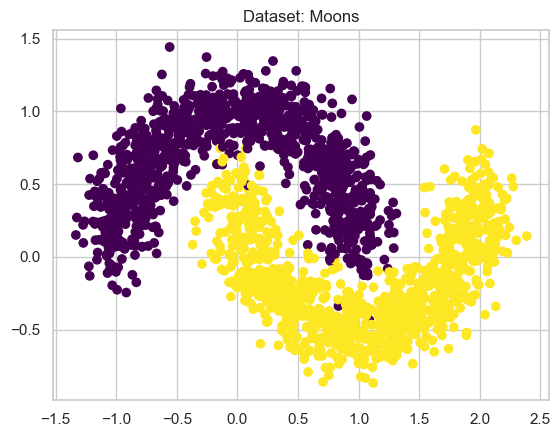

In [81]:
X_m, y_m = make_moons(2000, noise=0.15)
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, cmap='viridis')
plt.title("Dataset: Moons")
plt.show()

In [82]:
X_df = pd.DataFrame(X_m)
X_df

,0,1
0,1.711773,0.250793
1,0.374424,0.947715
2,0.492962,-0.294469
3,-0.945103,0.098870
4,0.534770,-0.362848
...,...,...
1995,0.188811,0.105396
1996,0.377031,-0.361935
1997,-0.951754,0.580367
1998,0.822696,-0.693060


In [83]:
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_m, y_m, test_size=0.2, stratify=y_m, random_state=42)

### Создание и обучение модели

In [84]:
my_classifier = GBMClassifier(n=MAX_TREES)
my_classifier.fit(X_m_train, y_m_train)


### Сравнение с классификатором XGBoost

In [85]:
xgb_classifier = xgb.XGBClassifier(n_estimators=MAX_TREES, random_state=42, n_jobs=-1)
xgb_classifier.fit(X_m_train, y_m_train)

my_preds = my_classifier.predict(X_m_test)
xgb_preds = xgb_classifier.predict(X_m_test)

print(f'my model\'s r2 score: {r2_score(y_m_test, my_preds)}')
print(f'xgb model\'s r2 score: {r2_score(y_m_test, xgb_preds)}')

my model's r2 score: 0.92
xgb model's r2 score: 0.95
